In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

import os
import re
import subprocess
from functools import reduce

In [7]:
# HDFS config
HDFS_BASE = "hdfs://namenode:8020"

HDFS_RAW_DIR = "/user/spark/ids/raw"
HDFS_RAW_GLOB = f"{HDFS_BASE}{HDFS_RAW_DIR}/*.csv"

OUTPUT_BASE = f"{HDFS_BASE}/user/spark/ids/processed"

PARQUET_BY_FILE = f"{OUTPUT_BASE}/parquet_by_file"
MERGED_DIR      = f"{OUTPUT_BASE}/parquet_merged"
CLEAN_DIR       = f"{OUTPUT_BASE}/parquet_clean"
CLEAN_CLIPPED_DIR = f"{OUTPUT_BASE}/parquet_clean_clipped"
BALANCED_DIR    = f"{OUTPUT_BASE}/parquet_balanced"
ENCODED_DIR     = f"{OUTPUT_BASE}/parquet_encoded"
TIME_DIR        = f"{OUTPUT_BASE}/parquet_time"
SPLIT_DIR       = f"{OUTPUT_BASE}/splits_stratified"
RF_DIR          = f"{OUTPUT_BASE}/rf_feature_importance"

RANDOM_STATE = 42

label_col = "Label"
ts_col = "Timestamp"
BAD_LABEL_VALUE = "Label"

print("HDFS raw glob:", HDFS_RAW_GLOB)
print("Output base:", OUTPUT_BASE)

HDFS raw glob: hdfs://namenode:8020/user/spark/ids/raw/*.csv
Output base: hdfs://namenode:8020/user/spark/ids/processed


In [3]:
spark = (
    SparkSession.builder
    .appName("IDS_Preprocessing_HDFS")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.network.timeout", "600s")
    .config("spark.executor.heartbeatInterval", "60s")
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:8020")
    .config("spark.hadoop.dfs.client.use.datanode.hostname", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/20 16:39:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/20 16:39:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [12]:
from py4j.java_gateway import java_import

hadoop_conf = spark._jsc.hadoopConfiguration()

# Import Java classes
java_import(spark._jvm, "java.net.URI")
java_import(spark._jvm, "org.apache.hadoop.fs.Path")
java_import(spark._jvm, "org.apache.hadoop.fs.FileSystem")

hdfs_uri = spark._jvm.URI("hdfs://namenode:8020")

# Force HDFS FileSystem (not local FS)
fs = spark._jvm.FileSystem.get(hdfs_uri, hadoop_conf)

# IMPORTANT: Path must be HDFS path WITHOUT scheme/authority
# If your folder is: hdfs://namenode:8020/user/spark/ids/raw
hdfs_path = spark._jvm.Path("/user/spark/ids/raw")

statuses = fs.listStatus(hdfs_path)

csv_files = []
for s in statuses:
    p = s.getPath().toString()
    if p.endswith(".csv"):
        csv_files.append(p)

csv_files = sorted(csv_files)

print(f"Found {len(csv_files)} CSV files:")
print("\n".join(csv_files[:10]))

Found 10 CSV files:
hdfs://namenode:8020/user/spark/ids/raw/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
hdfs://namenode:8020/user/spark/ids/raw/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


In [13]:
df0 = (spark.read
       .option("header", True)
       .option("inferSchema", True)
       .csv(csv_files[0]))

df0.printSchema()
df0.show(5, truncate=False)

df0.select(F.trim(F.col(label_col)).alias(label_col)) \
   .groupBy(label_col).count() \
   .orderBy(F.desc("count")).show(30, truncate=False)

root
 |-- Dst Port: integer (nullable = true)
 |-- Protocol: integer (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Tot Fwd Pkts: integer (nullable = true)
 |-- Tot Bwd Pkts: integer (nullable = true)
 |-- TotLen Fwd Pkts: integer (nullable = true)
 |-- TotLen Bwd Pkts: double (nullable = true)
 |-- Fwd Pkt Len Max: integer (nullable = true)
 |-- Fwd Pkt Len Min: integer (nullable = true)
 |-- Fwd Pkt Len Mean: double (nullable = true)
 |-- Fwd Pkt Len Std: double (nullable = true)
 |-- Bwd Pkt Len Max: integer (nullable = true)
 |-- Bwd Pkt Len Min: integer (nullable = true)
 |-- Bwd Pkt Len Mean: double (nullable = true)
 |-- Bwd Pkt Len Std: double (nullable = true)
 |-- Flow Byts/s: double (nullable = true)
 |-- Flow Pkts/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Flow IAT Max: double (nullable = true)
 |-- Flow IAT Min: double (nullable = tr

26/02/19 08:47:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+--------+-------------------+-------------+------------+------------+---------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+----------------+---------------+-----------+-----------+-------------+------------+------------+------------+-----------+------------+-----------+-----------+-----------+-----------+------------+-----------+-----------+-----------+-------------+-------------+-------------+-------------+--------------+--------------+-----------+-----------+-----------+-----------+------------+-----------+-----------+------------+------------+------------+------------+------------+------------+--------------+------------+-------------+------------+----------------+----------------+--------------+--------------+----------------+--------------+--------------+----------------+----------------+----------------+----------------+----------------+-----------------+-----------------+-----------------+------

[Stage 3:=======================================>                   (2 + 1) / 3]

+------+------+
|Label |count |
+------+------+
|Benign|762384|
|Bot   |286191|
+------+------+



In [15]:
def clean_numeric_features_spark(df, numeric_cols):
    # cast to double
    for c in numeric_cols:
        df = df.withColumn(c, F.col(c).cast("double"))

    # replace +/- inf with null
    pos_inf = float("inf")
    neg_inf = float("-inf")

    for c in numeric_cols:
        df = df.withColumn(
            c,
            F.when(F.col(c) == pos_inf, None)
             .when(F.col(c) == neg_inf, None)
             .otherwise(F.col(c))
        )
    return df

In [16]:
def impute_median_spark(df, numeric_cols, rel_error=0.001):
    medians = {}
    for c in numeric_cols:
        q = df.approxQuantile(c, [0.5], rel_error)
        med = q[0] if q and q[0] is not None else 0.0
        medians[c] = float(med)
    return df.fillna(medians)

In [17]:
junk_total = 0

for f in csv_files:
    dfi = spark.read.option("header", True).option("inferSchema", True).csv(f)
    dfi = dfi.withColumn(label_col, F.trim(F.col(label_col).cast("string")))
    junk_total += dfi.filter(F.col(label_col) == BAD_LABEL_VALUE).count()

print("Junk rows (Label == 'Label'):", junk_total)

[Stage 53:=============================>                            (1 + 1) / 2]

Junk rows (Label == 'Label'): 59


In [18]:
def preprocess_file_to_parquet(csv_path: str):
    df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .option("mode", "PERMISSIVE")
          .csv(csv_path))

    # label cleanup + remove junk header rows
    df = df.withColumn(label_col, F.trim(F.col(label_col).cast("string")))
    df = df.filter(F.col(label_col) != BAD_LABEL_VALUE)

    # numeric columns exclude label & timestamp
    numeric_cols = [c for c in df.columns if c not in [label_col, ts_col]]

    # clean + impute
    df = clean_numeric_features_spark(df, numeric_cols)
    df = impute_median_spark(df, numeric_cols)

    stem = os.path.splitext(os.path.basename(csv_path))[0]
    out_path = f"{PARQUET_BY_FILE}/{stem}"
    df.write.mode("overwrite").parquet(out_path)

    return stem, out_path, df.count()

total_rows = 0
for f in csv_files:
    stem, out_path, n = preprocess_file_to_parquet(f)
    total_rows += n
    print(f"Finished {stem} -> {out_path} | rows={n:,}")

print("Total rows processed:", f"{total_rows:,}")

Finished Friday-02-03-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Friday-02-03-2018_TrafficForML_CICFlowMeter | rows=1,048,575


Finished Friday-16-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Friday-16-02-2018_TrafficForML_CICFlowMeter | rows=1,048,574


Finished Friday-23-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Friday-23-02-2018_TrafficForML_CICFlowMeter | rows=1,048,575


Finished Thuesday-20-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Thuesday-20-02-2018_TrafficForML_CICFlowMeter | rows=7,948,748


Finished Thursday-01-03-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Thursday-01-03-2018_TrafficForML_CICFlowMeter | rows=331,100


...

Finished Thursday-22-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Thursday-22-02-2018_TrafficForML_CICFlowMeter | rows=1,048,575


Finished Wednesday-14-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Wednesday-14-02-2018_TrafficForML_CICFlowMeter | rows=1,048,575


Finished Wednesday-21-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Wednesday-21-02-2018_TrafficForML_CICFlowMeter | rows=1,048,575


[Stage 979:============================>                            (1 + 1) / 2]

Finished Wednesday-28-02-2018_TrafficForML_CICFlowMeter -> hdfs://namenode:8020/user/spark/ids/processed/parquet_by_file/Wednesday-28-02-2018_TrafficForML_CICFlowMeter | rows=613,071
Total rows processed: 16,232,943


In [19]:
df_merged = spark.read.parquet(f"{PARQUET_BY_FILE}/*")

print("Merged rows:", df_merged.count())
print("Merged cols:", len(df_merged.columns))

df_merged.write.mode("overwrite").parquet(MERGED_DIR)
print("Wrote merged parquet:", MERGED_DIR)

Merged rows: 16232943
Merged cols: 80


Wrote merged parquet: hdfs://namenode:8020/user/spark/ids/processed/parquet_merged


In [20]:
df_merged = spark.read.parquet(MERGED_DIR)

df_merged.groupBy(label_col).count() \
         .orderBy(F.desc("count")) \
         .show(40, truncate=False)

[Stage 988:====================================================>  (18 + 1) / 19]

+------------------------+--------+
|Label                   |count   |
+------------------------+--------+
|Benign                  |13484708|
|DDOS attack-HOIC        |686012  |
|DDoS attacks-LOIC-HTTP  |576191  |
|DoS attacks-Hulk        |461912  |
|Bot                     |286191  |
|FTP-BruteForce          |193360  |
|SSH-Bruteforce          |187589  |
|Infilteration           |161934  |
|DoS attacks-SlowHTTPTest|139890  |
|DoS attacks-GoldenEye   |41508   |
|DoS attacks-Slowloris   |10990   |
|DDOS attack-LOIC-UDP    |1730    |
|Brute Force -Web        |611     |
|Brute Force -XSS        |230     |
|SQL Injection           |87      |
+------------------------+--------+



In [22]:
numeric_cols = [c for c in df_merged.columns if c not in [label_col, ts_col]]

zero_cols = []
for c in numeric_cols:
    mx = df_merged.select(F.max(F.abs(F.col(c))).alias("mx")).collect()[0]["mx"]
    if mx is None or float(mx) == 0.0:
        zero_cols.append(c)

print("All-zero columns:", len(zero_cols))
print(zero_cols[:40])

All-zero columns: 8
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


In [23]:
df_clean = df_merged.withColumn(label_col, F.trim(F.col(label_col).cast("string")))
df_clean = df_clean.filter(F.col(label_col) != BAD_LABEL_VALUE)

if zero_cols:
    df_clean = df_clean.drop(*zero_cols)

df_clean.write.mode("overwrite").parquet(CLEAN_DIR)

print("Wrote clean parquet:", CLEAN_DIR)
print("Clean rows:", df_clean.count(), "| cols:", len(df_clean.columns))

Wrote clean parquet: hdfs://namenode:8020/user/spark/ids/processed/parquet_clean


[Stage 1226:==========================================>           (15 + 1) / 19]

Clean rows: 16232943 | cols: 72


In [6]:
import numpy as np

df_clean = spark.read.parquet(CLEAN_DIR)

exclude = {label_col, ts_col}
numeric_cols = [c for c in df_clean.columns if c not in exclude]

CLIP_Q = 0.995
REL_ERR = 0.001

clip_caps = {}

for c in numeric_cols:
    q = df_clean.approxQuantile(c, [CLIP_Q], REL_ERR)
    cap = q[0] if q and q[0] is not None else None
    if cap is not None and np.isfinite(cap) and abs(cap) > 0:
        clip_caps[c] = float(cap)

print(f"Computed caps for {len(clip_caps)} columns")

df_clip = df_clean
for c, cap in clip_caps.items():
    df_clip = df_clip.withColumn(
        c,
        F.when(F.col(c) > cap, F.lit(cap))
         .when(F.col(c) < -cap, F.lit(-cap))
         .otherwise(F.col(c))
    )

df_clip.write.mode("overwrite").parquet(CLEAN_CLIPPED_DIR)

print("Wrote clipped parquet:", CLEAN_CLIPPED_DIR)

Computed caps for 68 columns


NameError: name 'CLEAN_CLIPPEDE_DIR' is not defined

In [9]:
df_clip.write.mode("overwrite").parquet(CLEAN_CLIPPED_DIR)

print("Wrote clipped parquet:", CLEAN_CLIPPED_DIR)

26/02/20 16:58:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Wrote clipped parquet: hdfs://namenode:8020/user/spark/ids/processed/parquet_clean_clipped


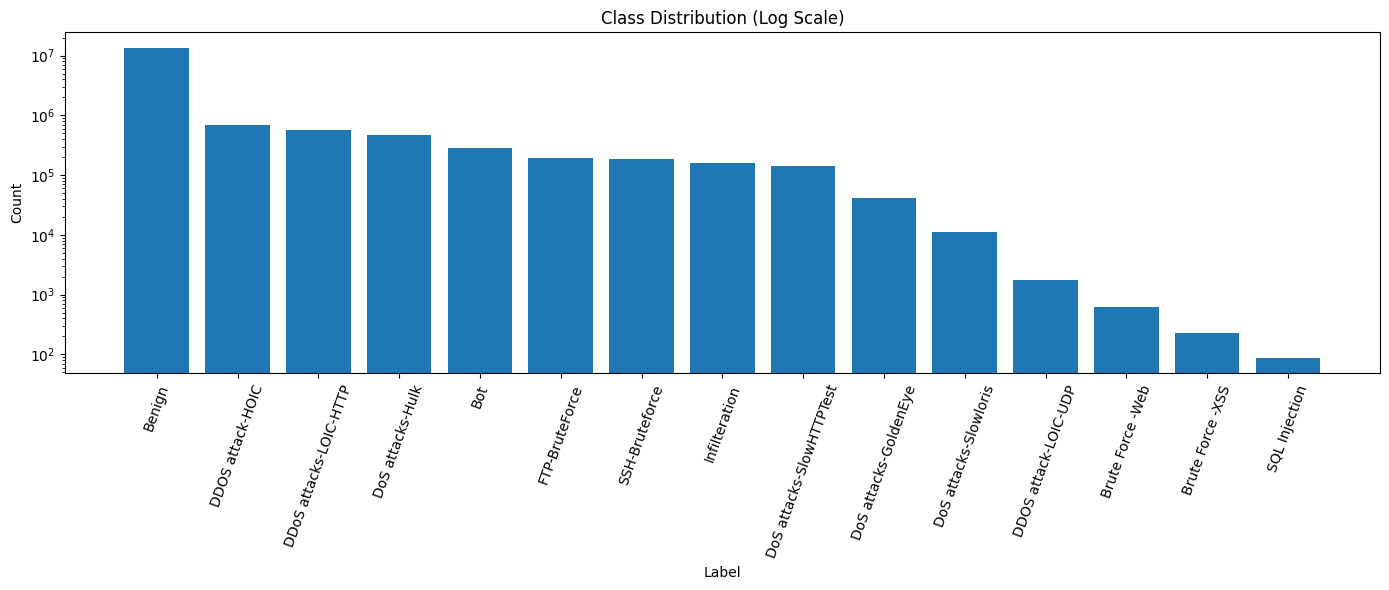

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Spark aggregation (already computed but recomputing is fine)
dist = (
    df_clip.groupBy("Label")
    .count()
    .orderBy(F.desc("count"))
)

# Convert small aggregated result to pandas
dist_pd = dist.toPandas()

# Plot
plt.figure(figsize=(14,6))
plt.bar(dist_pd["Label"], dist_pd["count"])
plt.xticks(rotation=70)
plt.yscale("log")   # important for IDS datasets (Benign dominates)
plt.title("Class Distribution (Log Scale)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

In [11]:
(dist.coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(f"{OUTPUT_BASE}/class_distribution"))

In [12]:
TARGET_BENIGN = 3_000_000

counts = {r[label_col]: r["count"] for r in df_clip.groupBy(label_col).count().collect()}
benign_count = counts.get("Benign", 0)
print("Benign count:", benign_count)

df_benign = df_clip.filter(F.col(label_col) == "Benign")
df_other  = df_clip.filter(F.col(label_col) != "Benign")

if benign_count > TARGET_BENIGN:
    frac = TARGET_BENIGN / benign_count
    df_benign_ds = df_benign.sample(False, frac, seed=RANDOM_STATE)
else:
    df_benign_ds = df_benign

df_bal = df_other.unionByName(df_benign_ds)

df_bal.write.mode("overwrite").parquet(BALANCED_DIR)
print("Wrote balanced parquet:", BALANCED_DIR)
print("Balanced rows:", df_bal.count())

Benign count: 13484708


Wrote balanced parquet: hdfs://namenode:8020/user/spark/ids/processed/parquet_balanced


Balanced rows: 5751368


In [13]:
df_bal = spark.read.parquet(BALANCED_DIR)
df_bal.groupBy(label_col).count().orderBy(F.desc("count")).show(50, truncate=False)

+------------------------+-------+
|Label                   |count  |
+------------------------+-------+
|Benign                  |3003133|
|DDOS attack-HOIC        |686012 |
|DDoS attacks-LOIC-HTTP  |576191 |
|DoS attacks-Hulk        |461912 |
|Bot                     |286191 |
|FTP-BruteForce          |193360 |
|SSH-Bruteforce          |187589 |
|Infilteration           |161934 |
|DoS attacks-SlowHTTPTest|139890 |
|DoS attacks-GoldenEye   |41508  |
|DoS attacks-Slowloris   |10990  |
|DDOS attack-LOIC-UDP    |1730   |
|Brute Force -Web        |611    |
|Brute Force -XSS        |230    |
|SQL Injection           |87     |
+------------------------+-------+



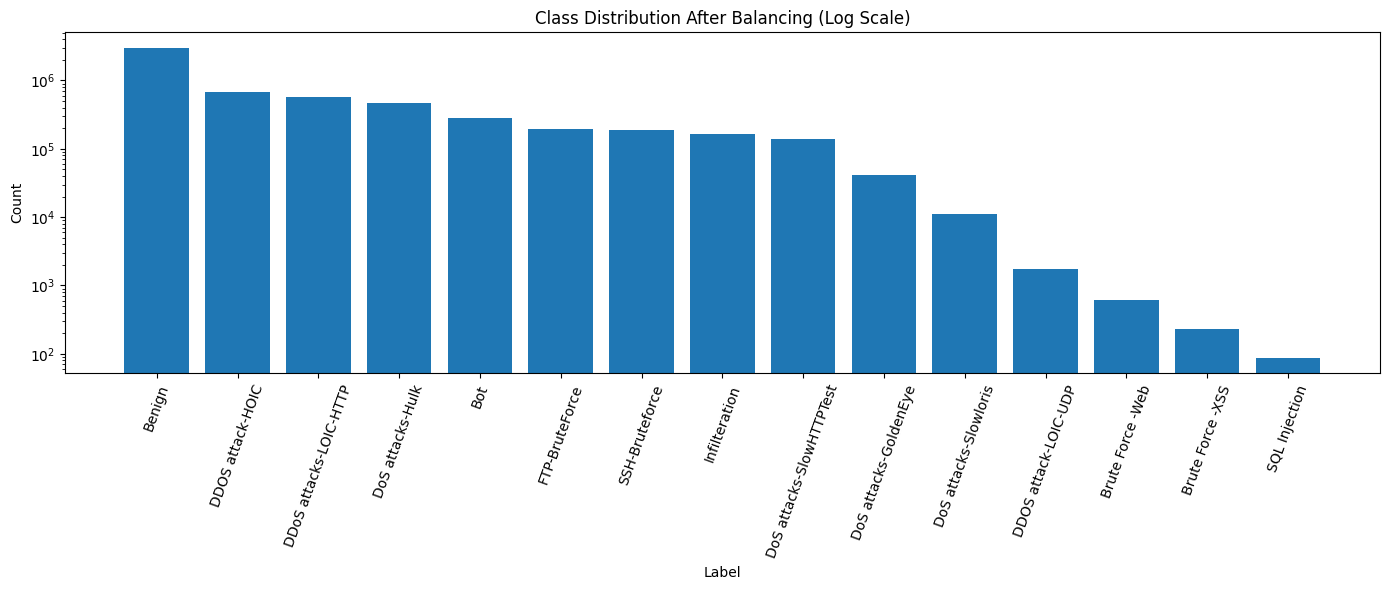

In [14]:
# Spark aggregation
dist = (
    df_bal.groupBy("Label")
    .count()
    .orderBy(F.desc("count"))
)

# Convert small aggregated result to pandas
dist_pd = dist.toPandas()

# Plot
plt.figure(figsize=(14,6))
plt.bar(dist_pd["Label"], dist_pd["count"])
plt.xticks(rotation=70)
plt.yscale("log")   # important for IDS datasets (Benign dominates)
plt.title("Class Distribution After Balancing (Log Scale)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

In [15]:
from pyspark.ml.feature import StringIndexer

df_bal = spark.read.parquet(BALANCED_DIR)

indexer = StringIndexer(
    inputCol=label_col,
    outputCol="label_idx",
    handleInvalid="keep"
).fit(df_bal)

df_enc = indexer.transform(df_bal)

df_enc.write.mode("overwrite").parquet(ENCODED_DIR)

mapping = [(i, lab) for i, lab in enumerate(indexer.labels)]
map_df = spark.createDataFrame(mapping, ["label_idx", "label_name"])

(map_df.coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(f"{OUTPUT_BASE}/label_mapping"))

print("Wrote encoded parquet:", ENCODED_DIR)

[Stage 218:>                                                        (0 + 1) / 1]

Wrote encoded parquet: hdfs://namenode:8020/user/spark/ids/processed/parquet_encoded


In [16]:
df_enc = spark.read.parquet(ENCODED_DIR)

ts_parsed = F.to_timestamp(F.col(ts_col), "dd/MM/yyyy HH:mm:ss")

df_time = (df_enc
           .withColumn("ts_parsed", ts_parsed)
           .withColumn("timestamp_unix", F.col("ts_parsed").cast("long"))
           .drop("ts_parsed"))

df_time.write.mode("overwrite").parquet(TIME_DIR)

df_time.select(ts_col, "timestamp_unix").show(10, truncate=False)
print("Null timestamps:", df_time.filter(F.col("timestamp_unix").isNull()).count())

+-------------------+--------------+
|Timestamp          |timestamp_unix|
+-------------------+--------------+
|20/02/2018 10:28:58|1519122538    |
|20/02/2018 11:03:53|1519124633    |
|20/02/2018 11:03:53|1519124633    |
|20/02/2018 11:03:53|1519124633    |
|20/02/2018 10:28:58|1519122538    |
|20/02/2018 10:28:58|1519122538    |
|20/02/2018 10:27:17|1519122437    |
|20/02/2018 10:27:18|1519122438    |
|20/02/2018 11:03:53|1519124633    |
|20/02/2018 10:28:58|1519122538    |
+-------------------+--------------+
only showing top 10 rows



Null timestamps: 0


In [17]:
df_time = spark.read.parquet(TIME_DIR)

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

df_r = df_time.withColumn("rand", F.rand(seed=RANDOM_STATE))

train = df_r.filter(F.col("rand") < TRAIN_FRAC).drop("rand")
val   = df_r.filter((F.col("rand") >= TRAIN_FRAC) & (F.col("rand") < TRAIN_FRAC + VAL_FRAC)).drop("rand")
test  = df_r.filter(F.col("rand") >= TRAIN_FRAC + VAL_FRAC).drop("rand")

print("Train:", train.count(), "Val:", val.count(), "Test:", test.count())

train.write.mode("overwrite").parquet(f"{SPLIT_DIR}/train")
val.write.mode("overwrite").parquet(f"{SPLIT_DIR}/val")
test.write.mode("overwrite").parquet(f"{SPLIT_DIR}/test")

print("Wrote splits:", SPLIT_DIR)

Train: 4026287 Val: 861484 Test: 863597


Wrote splits: hdfs://namenode:8020/user/spark/ids/processed/splits_stratified


In [18]:
train_df = spark.read.parquet(f"{SPLIT_DIR}/train")
val_df   = spark.read.parquet(f"{SPLIT_DIR}/val")
test_df  = spark.read.parquet(f"{SPLIT_DIR}/test")

print("Train dist:")
train_df.groupBy(label_col).count().orderBy(F.desc("count")).show(20, truncate=False)

print("Val dist:")
val_df.groupBy(label_col).count().orderBy(F.desc("count")).show(20, truncate=False)

print("Test dist:")
test_df.groupBy(label_col).count().orderBy(F.desc("count")).show(20, truncate=False)

Train dist:


+------------------------+-------+
|Label                   |count  |
+------------------------+-------+
|Benign                  |2101779|
|DDOS attack-HOIC        |480487 |
|DDoS attacks-LOIC-HTTP  |403712 |
|DoS attacks-Hulk        |323545 |
|Bot                     |200481 |
|FTP-BruteForce          |135308 |
|SSH-Bruteforce          |131275 |
|Infilteration           |112995 |
|DoS attacks-SlowHTTPTest|98038  |
|DoS attacks-GoldenEye   |29174  |
|DoS attacks-Slowloris   |7667   |
|DDOS attack-LOIC-UDP    |1189   |
|Brute Force -Web        |425    |
|Brute Force -XSS        |156    |
|SQL Injection           |56     |
+------------------------+-------+

Val dist:
+------------------------+------+
|Label                   |count |
+------------------------+------+
|Benign                  |449738|
|DDOS attack-HOIC        |102673|
|DDoS attacks-LOIC-HTTP  |86218 |
|DoS attacks-Hulk        |69352 |
|Bot                     |42793 |
|FTP-BruteForce          |29036 |
|SSH-Bruteforce   

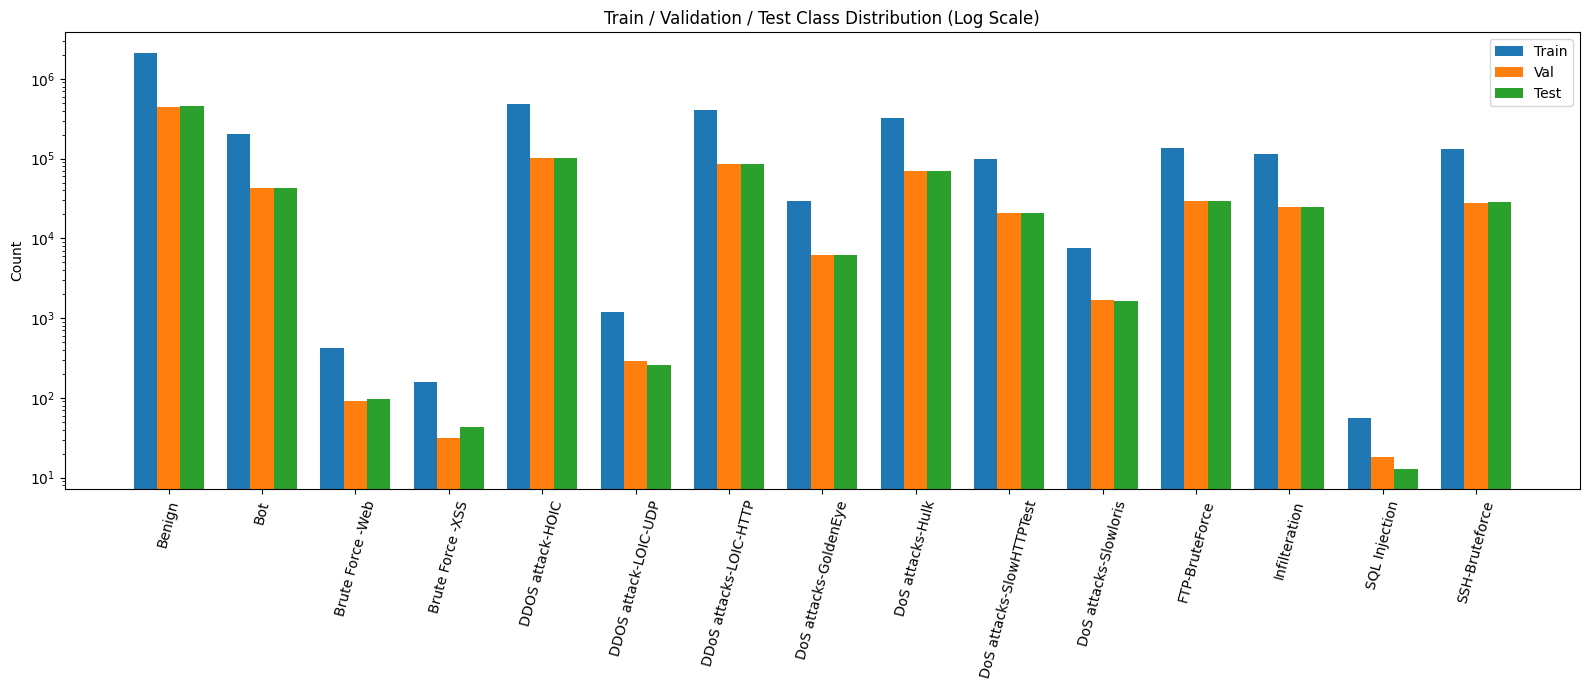

In [19]:
# Function to get pandas distribution safely
def get_dist_pd(df):
    dist = (
        df.groupBy("Label")
          .count()
          .orderBy("Label")   # consistent ordering
    )
    return dist.toPandas()

# Get distributions
train_pd = get_dist_pd(train_df)
val_pd   = get_dist_pd(val_df)
test_pd  = get_dist_pd(test_df)

# Merge into one dataframe for plotting
merged = train_pd.merge(val_pd, on="Label", suffixes=("_train", "_val"))
merged = merged.merge(test_pd, on="Label")
merged.rename(columns={"count": "count_test"}, inplace=True)

# Plot
plt.figure(figsize=(16,7))

x = range(len(merged["Label"]))

plt.bar(x, merged["count_train"], width=0.25, label="Train")
plt.bar([i + 0.25 for i in x], merged["count_val"], width=0.25, label="Val")
plt.bar([i + 0.5 for i in x], merged["count_test"], width=0.25, label="Test")

plt.xticks([i + 0.25 for i in x], merged["Label"], rotation=75)
plt.yscale("log")  # important because Benign dominates
plt.title("Train / Validation / Test Class Distribution (Log Scale)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

train_df = spark.read.parquet(f"{SPLIT_DIR}/train")

drop_cols = {label_col, "label_idx", ts_col}
feature_cols = [c for c in train_df.columns if c not in drop_cols]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_vec = assembler.transform(train_df).select(F.col("label_idx").cast("double").alias("label"), "features")

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=200,
    seed=RANDOM_STATE
)

rf_model = rf.fit(train_vec)

importances = rf_model.featureImportances.toArray().tolist()
pairs = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

print("Top 30 features:")
for f, s in pairs[:30]:
    print(f"{f:45s} {s:.6f}")

imp_df = spark.createDataFrame([(f, float(s)) for f, s in pairs], ["feature", "importance"])

(imp_df.coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(RF_DIR))

print("Saved RF feature importance:", RF_DIR)

26/02/20 17:46:01 WARN DAGScheduler: Broadcasting large task binary with size 1049.0 KiB
26/02/20 17:52:16 WARN DAGScheduler: Broadcasting large task binary with size 2000.9 KiB
                                                                                

Top 30 features:
Init Fwd Win Byts                             0.123320
Dst Port                                      0.058036
Fwd Seg Size Min                              0.054951
timestamp_unix                                0.053568
Fwd Pkt Len Max                               0.046834
Fwd Header Len                                0.042333
Subflow Fwd Byts                              0.038937
TotLen Fwd Pkts                               0.036362
Flow Duration                                 0.027636
Flow IAT Max                                  0.026469
Fwd IAT Min                                   0.026447
Flow IAT Min                                  0.026023
Fwd Pkts/s                                    0.025381
Fwd Seg Size Avg                              0.024236
Flow Pkts/s                                   0.024084
Flow IAT Mean                                 0.023507
Fwd IAT Max                                   0.021806
Fwd Pkt Len Mean                              0.

[Stage 292:>                                                        (0 + 1) / 1]

Saved RF feature importance: hdfs://namenode:8020/user/spark/ids/processed/rf_feature_importance


In [21]:
spark.stop()